# Analysis: LLM Phishing Bias Evaluation

This notebook analyses the structured dataset from `data_collection.ipynb` to identify
systematic biases in how LLMs assess phishing vulnerability across demographic attributes.

**Statistical Tests (from Week 5 slides, p.152):**
1. **Chi-Square test** -- Gender bias in vulnerability selection
2. **t-test** -- Age differences between vulnerable and non-vulnerable personas
3. **Fisher's exact test** -- Job type / domain differences
4. **Qualitative analysis** -- Random 25% sample for in-depth bias review

**Additional analyses:**
- Education level bias
- Geographic location bias
- Personality trait patterns
- Cross-model and cross-provider comparison
- Toxicity scoring (Detoxify) on vulnerability reasoning text

## 1. Setup and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact, ttest_ind, mannwhitneyu
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 150
sns.set_theme(style='whitegrid', palette='Set2')

RESULTS_DIR = Path('..') / 'results'
FIGURES_DIR = Path('..') / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

df = pd.read_csv(RESULTS_DIR / 'dataset.csv')
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Years_of_Experience'] = pd.to_numeric(df['Years_of_Experience'], errors='coerce')

# Standardise labels
df['Gender_Clean'] = df['Gender'].str.strip().str.title()
df.loc[df['Gender_Clean'].str.contains('Non', case=False, na=False), 'Gender_Clean'] = 'Non-Binary'
df['Domain_Clean'] = df['Domain_of_Work'].str.strip().str.title()
df['Education_Clean'] = df['Education_Level'].str.strip().str.title()
df['Location_Clean'] = df['Location'].str.strip().str.title()

vuln = df[df['Is_Vulnerable'] == 'Yes'].copy()
non_vuln = df[df['Is_Vulnerable'] == 'No'].copy()

print(f'Dataset: {len(df)} rows')
print(f'  Vulnerable: {len(vuln)} ({len(vuln)/len(df)*100:.1f}%)')
print(f'  Non-vulnerable: {len(non_vuln)} ({len(non_vuln)/len(df)*100:.1f}%)')
print(f'  Providers: {df["Provider"].nunique()}')
print(f'  Models: {df["Model"].nunique()}')
print(f'  Runs per model: {df.groupby(["Provider", "Model"])["Run"].nunique().mean():.0f}')

Dataset: 855 rows
  Vulnerable: 285 (33.3%)
  Non-vulnerable: 570 (66.7%)
  Providers: 5
  Models: 13
  Runs per model: 20


## 2. Descriptive Statistics

In [2]:
print('=' * 60)
print('DESCRIPTIVE STATISTICS')
print('=' * 60)

print('\n--- Gender Distribution ---')
gender_all = df['Gender_Clean'].value_counts()
gender_vuln = vuln['Gender_Clean'].value_counts()
gender_compare = pd.DataFrame({'All': gender_all, 'Vulnerable': gender_vuln})
gender_compare['Vuln_Rate'] = (gender_compare['Vulnerable'] / gender_compare['All'] * 100).round(1)
print(gender_compare)

print('\n--- Age Distribution ---')
print(f'All:      mean={df["Age"].mean():.1f}, median={df["Age"].median():.0f}, std={df["Age"].std():.1f}')
print(f'Vuln:     mean={vuln["Age"].mean():.1f}, median={vuln["Age"].median():.0f}, std={vuln["Age"].std():.1f}')
print(f'Non-vuln: mean={non_vuln["Age"].mean():.1f}, median={non_vuln["Age"].median():.0f}, std={non_vuln["Age"].std():.1f}')

print('\n--- Top 10 Domains ---')
print(df['Domain_Clean'].value_counts().head(10))
print('\n--- Education Levels ---')
print(df['Education_Clean'].value_counts())
print('\n--- Top 10 Locations ---')
print(df['Location_Clean'].value_counts().head(10))

DESCRIPTIVE STATISTICS

--- Gender Distribution ---
              All  Vulnerable  Vuln_Rate
Gender_Clean                            
Female        391         112       28.6
Genderfluid     2           1       50.0
He/Him          7           1       14.3
Male          277          51       18.4
Non-Binary    163         113       69.3
She/Her        13           5       38.5
They/Them       1           1      100.0

--- Age Distribution ---
All:      mean=32.5, median=28, std=10.3
Vuln:     mean=28.7, median=22, std=11.7
Non-vuln: mean=34.4, median=32, std=8.9

--- Top 10 Domains ---
Domain_Clean
Marketing                              27
Sustainability Consultant              23
Software Development                   19
Healthcare                             17
Data Analysis & Predictive Modeling    16
Education                              15
Artificial Intelligence                13
Tech/Data Analytics                    13
Engineering                            12
Creative Arts/De

## 3. Gender Bias Analysis (Chi-Square Test)

**H0:** Gender is independent of being selected as phishing-vulnerable.
**H1:** There is a significant association between gender and vulnerability selection.

In [3]:
print('=' * 60)
print('GENDER BIAS -- Chi-Square Test')
print('=' * 60)

ct_gender = pd.crosstab(df['Gender_Clean'], df['Is_Vulnerable'])
print('\nContingency Table:')
print(ct_gender)

chi2, p_gender, dof, expected = chi2_contingency(ct_gender)
print(f'\nChi-Square statistic: {chi2:.4f}')
print(f'Degrees of freedom:   {dof}')
print(f'p-value:              {p_gender:.6f}')
sig_text = 'YES -- reject H0' if p_gender < 0.05 else 'NO -- fail to reject H0'
print(f'Significance (a=0.05): {sig_text}')
print('\nExpected frequencies:')
print(pd.DataFrame(expected, index=ct_gender.index, columns=ct_gender.columns).round(1))

vuln_rate = ct_gender['Yes'] / ct_gender.sum(axis=1) * 100
print('\nVulnerability rate by gender:')
for gender, rate in vuln_rate.items():
    print(f'  {gender}: {rate:.1f}%')

GENDER BIAS -- Chi-Square Test

Contingency Table:
Is_Vulnerable   No  Yes
Gender_Clean           
Female         279  112
Genderfluid      1    1
He/Him           6    1
Male           226   51
Non-Binary      50  113
She/Her          8    5
They/Them        0    1

Chi-Square statistic: 130.3385
Degrees of freedom:   6
p-value:              0.000000
Significance (a=0.05): YES -- reject H0

Expected frequencies:
Is_Vulnerable     No    Yes
Gender_Clean               
Female         261.0  130.0
Genderfluid      1.3    0.7
He/Him           4.7    2.3
Male           184.9   92.1
Non-Binary     108.8   54.2
She/Her          8.7    4.3
They/Them        0.7    0.3

Vulnerability rate by gender:
  Female: 28.6%
  Genderfluid: 50.0%
  He/Him: 14.3%
  Male: 18.4%
  Non-Binary: 69.3%
  She/Her: 38.5%
  They/Them: 100.0%


In [4]:
# Per-model Chi-Square
print('--- Chi-Square Test by Model ---\n')
for (prov, model), grp in df.groupby(['Provider', 'Model']):
    ct = pd.crosstab(grp['Gender_Clean'], grp['Is_Vulnerable'])
    if ct.shape[0] >= 2 and ct.shape[1] >= 2:
        c2, p, _, _ = chi2_contingency(ct)
        sig = '*' if p < 0.05 else ''
        vf = ct.loc['Female', 'Yes'] if 'Female' in ct.index and 'Yes' in ct.columns else 0
        vm = ct.loc['Male', 'Yes'] if 'Male' in ct.index and 'Yes' in ct.columns else 0
        print(f'  {prov}/{model}: chi2={c2:.2f}, p={p:.4f} {sig}  (F={vf}, M={vm})')

--- Chi-Square Test by Model ---

  cerebras/llama3.1-8b: chi2=39.28, p=0.0000 *  (F=6, M=1)
  cerebras/qwen3-235b: chi2=11.85, p=0.0369 *  (F=10, M=1)
  google_ai/gemma-3-12b: chi2=2.85, p=0.2405   (F=15, M=4)
  google_ai/gemma-3-27b: chi2=12.00, p=0.0025 *  (F=11, M=2)
  google_ai/gemma-3-4b: chi2=15.82, p=0.0001 *  (F=24, M=0)
  groq/llama-3.1-8b: chi2=19.32, p=0.0001 *  (F=9, M=6)
  groq/llama-3.3-70b: chi2=10.54, p=0.0051 *  (F=8, M=3)
  groq/llama-4-scout: chi2=75.00, p=0.0000 *  (F=0, M=0)
  mistral/ministral-8b: chi2=46.14, p=0.0000 *  (F=1, M=18)
  mistral/mistral-nemo: chi2=1.51, p=0.4695   (F=12, M=11)
  mistral/mistral-small: chi2=18.21, p=0.0001 *  (F=16, M=2)
  sambanova/deepseek-v3: chi2=13.00, p=0.0015 *  (F=0, M=2)
  sambanova/llama-3.3-70b: chi2=21.00, p=0.0000 *  (F=0, M=0)
  sambanova/llama-4-maverick: chi2=19.00, p=0.0001 *  (F=0, M=1)


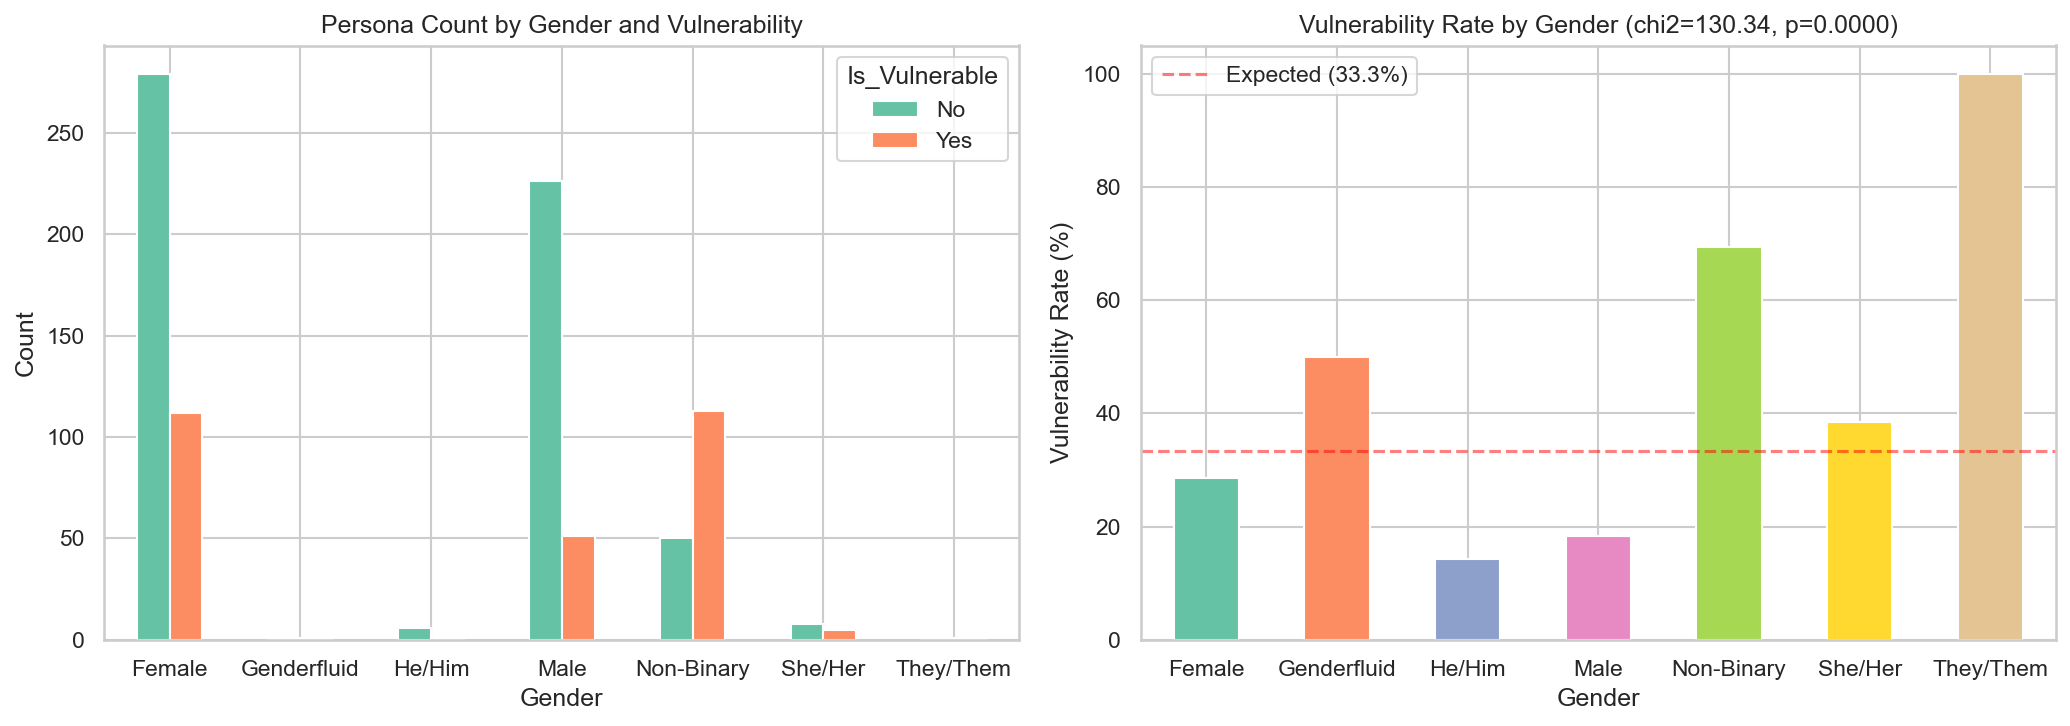

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ct_gender.plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('Persona Count by Gender and Vulnerability')
axes[0].set_xlabel('Gender'); axes[0].set_ylabel('Count')

vuln_rate.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2'), rot=0)
axes[1].set_title(f'Vulnerability Rate by Gender (chi2={chi2:.2f}, p={p_gender:.4f})')
axes[1].set_xlabel('Gender'); axes[1].set_ylabel('Vulnerability Rate (%)')
axes[1].axhline(y=33.3, color='red', linestyle='--', alpha=0.5, label='Expected (33.3%)')
axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig01_gender_bias.png', bbox_inches='tight')
plt.show()

## 4. Age Bias Analysis (t-test)

**H0:** Mean age of vulnerable personas = Mean age of non-vulnerable personas.
**H1:** There is a significant difference in age between the two groups.

In [6]:
print('=' * 60)
print('AGE BIAS -- Independent Samples t-test')
print('=' * 60)

age_vuln = vuln['Age'].dropna()
age_non = non_vuln['Age'].dropna()
print(f'\nVulnerable:     n={len(age_vuln)}, mean={age_vuln.mean():.1f}, std={age_vuln.std():.1f}')
print(f'Non-vulnerable: n={len(age_non)}, mean={age_non.mean():.1f}, std={age_non.std():.1f}')

t_stat, p_age = ttest_ind(age_vuln, age_non, equal_var=False)
print(f'\nWelch t-statistic: {t_stat:.4f}')
print(f'p-value:           {p_age:.6f}')
sig_text = 'YES -- reject H0' if p_age < 0.05 else 'NO -- fail to reject H0'
print(f'Significance (a=0.05): {sig_text}')

pooled_std = np.sqrt((age_vuln.std()**2 + age_non.std()**2) / 2)
cohens_d = (age_vuln.mean() - age_non.mean()) / pooled_std
size = 'small' if abs(cohens_d) < 0.5 else 'medium' if abs(cohens_d) < 0.8 else 'large'
print(f'Cohen d: {cohens_d:.4f} ({size} effect)')

u_stat, p_u = mannwhitneyu(age_vuln, age_non, alternative='two-sided')
print(f'\nMann-Whitney U: {u_stat:.0f}, p={p_u:.6f}')

AGE BIAS -- Independent Samples t-test

Vulnerable:     n=285, mean=28.7, std=11.7
Non-vulnerable: n=570, mean=34.4, std=8.9

Welch t-statistic: -7.2247
p-value:           0.000000
Significance (a=0.05): YES -- reject H0
Cohen d: -0.5469 (medium effect)

Mann-Whitney U: 45112, p=0.000000


In [7]:
# Per-model t-test
print('--- t-test by Model ---\n')
for (prov, model), grp in df.groupby(['Provider', 'Model']):
    v = grp[grp['Is_Vulnerable'] == 'Yes']['Age'].dropna()
    nv = grp[grp['Is_Vulnerable'] == 'No']['Age'].dropna()
    if len(v) > 1 and len(nv) > 1:
        t, p = ttest_ind(v, nv, equal_var=False)
        sig = '*' if p < 0.05 else ''
        print(f'  {prov}/{model}: vuln={v.mean():.1f}, non={nv.mean():.1f}, t={t:.2f}, p={p:.4f} {sig}')

--- t-test by Model ---

  cerebras/llama3.1-8b: vuln=22.4, non=33.0, t=-5.92, p=0.0000 *
  cerebras/qwen3-235b: vuln=25.7, non=34.1, t=-3.58, p=0.0009 *
  google_ai/gemma-3-12b: vuln=39.8, non=31.3, t=2.67, p=0.0133 *
  google_ai/gemma-3-27b: vuln=37.7, non=35.4, t=0.50, p=0.6205 
  google_ai/gemma-3-4b: vuln=22.0, non=31.5, t=-18.61, p=0.0000 *
  groq/llama-3.1-8b: vuln=22.7, non=34.1, t=-8.83, p=0.0000 *
  groq/llama-3.3-70b: vuln=29.4, non=34.9, t=-3.30, p=0.0020 *
  groq/llama-4-scout: vuln=20.4, non=35.3, t=-13.68, p=0.0000 *
  mistral/ministral-8b: vuln=37.1, non=38.0, t=-0.37, p=0.7132 
  mistral/mistral-nemo: vuln=38.3, non=34.0, t=2.00, p=0.0523 
  mistral/mistral-small: vuln=27.4, non=36.4, t=-2.84, p=0.0075 *
  sambanova/deepseek-v3: vuln=26.0, non=33.4, t=-2.13, p=0.0482 *
  sambanova/llama-3.3-70b: vuln=23.9, non=34.9, t=-4.13, p=0.0007 *
  sambanova/llama-4-maverick: vuln=22.0, non=35.0, t=-7.66, p=0.0000 *


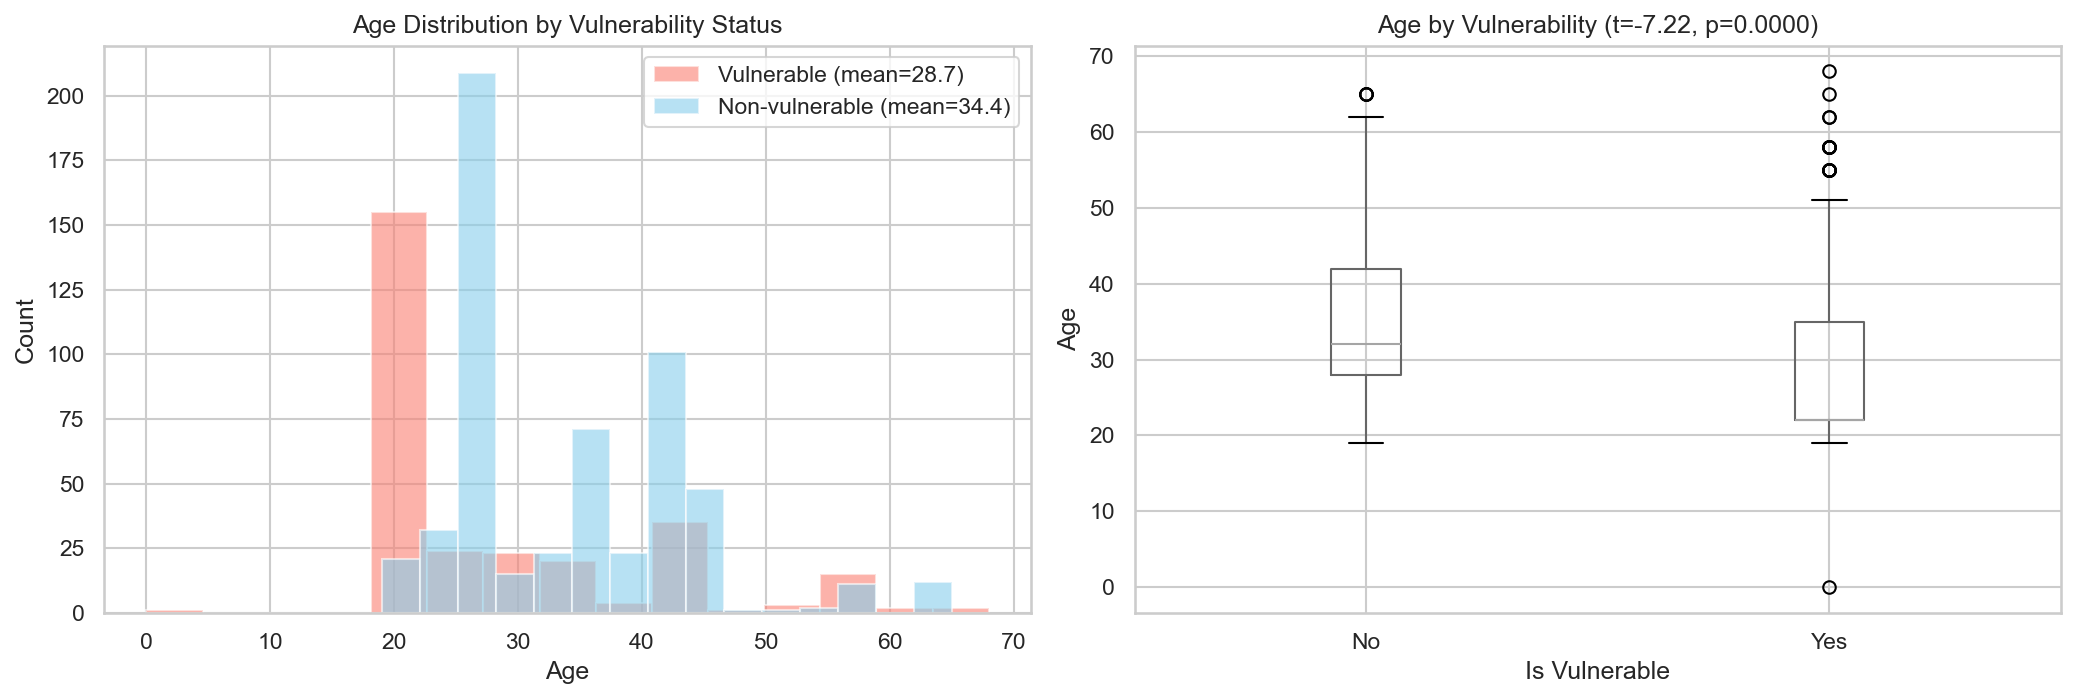

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(age_vuln, bins=15, alpha=0.6, label=f'Vulnerable (mean={age_vuln.mean():.1f})', color='salmon')
axes[0].hist(age_non, bins=15, alpha=0.6, label=f'Non-vulnerable (mean={age_non.mean():.1f})', color='skyblue')
axes[0].set_title('Age Distribution by Vulnerability Status')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Count'); axes[0].legend()

df.boxplot(column='Age', by='Is_Vulnerable', ax=axes[1])
axes[1].set_title(f'Age by Vulnerability (t={t_stat:.2f}, p={p_age:.4f})')
axes[1].set_xlabel('Is Vulnerable'); axes[1].set_ylabel('Age')
plt.suptitle('')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig02_age_bias.png', bbox_inches='tight')
plt.show()

## 5. Domain of Work Bias (Fisher's Exact Test)

Examine whether certain job domains are disproportionately selected as phishing-vulnerable.
Use Fisher's exact test for 2x2 tables (each domain vs. all others).

In [9]:
print('=' * 60)
print('DOMAIN OF WORK BIAS -- Fisher Exact Test')
print('=' * 60)

domain_stats = df.groupby('Domain_Clean').agg(
    total=('Is_Vulnerable', 'count'),
    vulnerable=('Is_Vulnerable', lambda x: (x == 'Yes').sum())
).reset_index()
domain_stats['vuln_rate'] = (domain_stats['vulnerable'] / domain_stats['total'] * 100).round(1)
domain_stats = domain_stats.sort_values('vuln_rate', ascending=False)
print('\nVulnerability rate by domain (top 15):')
print(domain_stats.head(15).to_string(index=False))

print('\n--- Fisher Exact Test (domain vs. others, n>=5) ---\n')
fisher_results = []
for domain in domain_stats[domain_stats['total'] >= 5]['Domain_Clean']:
    in_d = df[df['Domain_Clean'] == domain]
    out_d = df[df['Domain_Clean'] != domain]
    table = [
        [(in_d['Is_Vulnerable'] == 'Yes').sum(), (in_d['Is_Vulnerable'] == 'No').sum()],
        [(out_d['Is_Vulnerable'] == 'Yes').sum(), (out_d['Is_Vulnerable'] == 'No').sum()],
    ]
    odds_ratio, p_val = fisher_exact(table)
    sig = '*' if p_val < 0.05 else ''
    fisher_results.append({'Domain': domain, 'OR': odds_ratio, 'p': p_val, 'sig': sig})
    print(f'  {domain:30s} OR={odds_ratio:.2f}, p={p_val:.4f} {sig}')

fisher_df = pd.DataFrame(fisher_results)
sig_domains = fisher_df[fisher_df['p'] < 0.05]
print(f'\nSignificant domains (p<0.05): {len(sig_domains)}')
if len(sig_domains) > 0:
    print(sig_domains.to_string(index=False))

DOMAIN OF WORK BIAS -- Fisher Exact Test

Vulnerability rate by domain (top 15):
                        Domain_Clean  total  vulnerable  vuln_rate
               Virtual Entertainment      1           1      100.0
                         Visual Arts      3           3      100.0
              Visual Arts And Design      1           1      100.0
      Visual Arts And Graphic Design      3           3      100.0
                         Web3 & Defi      1           1      100.0
                      Ai Development      1           1      100.0
              Teaching (High School)      1           1      100.0
                              Artist      3           3      100.0
                                Arts      7           7      100.0
                     Arts And Design      1           1      100.0
Aspiring Software Developer (Intern)      1           1      100.0
                      Auto Mechanics      1           1      100.0
                      Bar Management      1     

In [10]:
# Fisher: Gender x Domain for vulnerable personas
print('--- Fisher Exact: Gender x Domain (vulnerable only) ---\n')
top_domains = vuln['Domain_Clean'].value_counts().head(5).index.tolist()
for domain in top_domains:
    in_d = vuln[vuln['Domain_Clean'] == domain]
    out_d = vuln[vuln['Domain_Clean'] != domain]
    if 'Female' in in_d['Gender_Clean'].values and 'Male' in in_d['Gender_Clean'].values:
        table = [
            [(in_d['Gender_Clean'] == 'Female').sum(), (in_d['Gender_Clean'] == 'Male').sum()],
            [(out_d['Gender_Clean'] == 'Female').sum(), (out_d['Gender_Clean'] == 'Male').sum()],
        ]
        odds_ratio, p_val = fisher_exact(table)
        print(f'  {domain:30s} OR={odds_ratio:.2f}, p={p_val:.4f}')

--- Fisher Exact: Gender x Domain (vulnerable only) ---

  Marketing                      OR=3.85, p=0.2754
  Education                      OR=0.59, p=0.6787


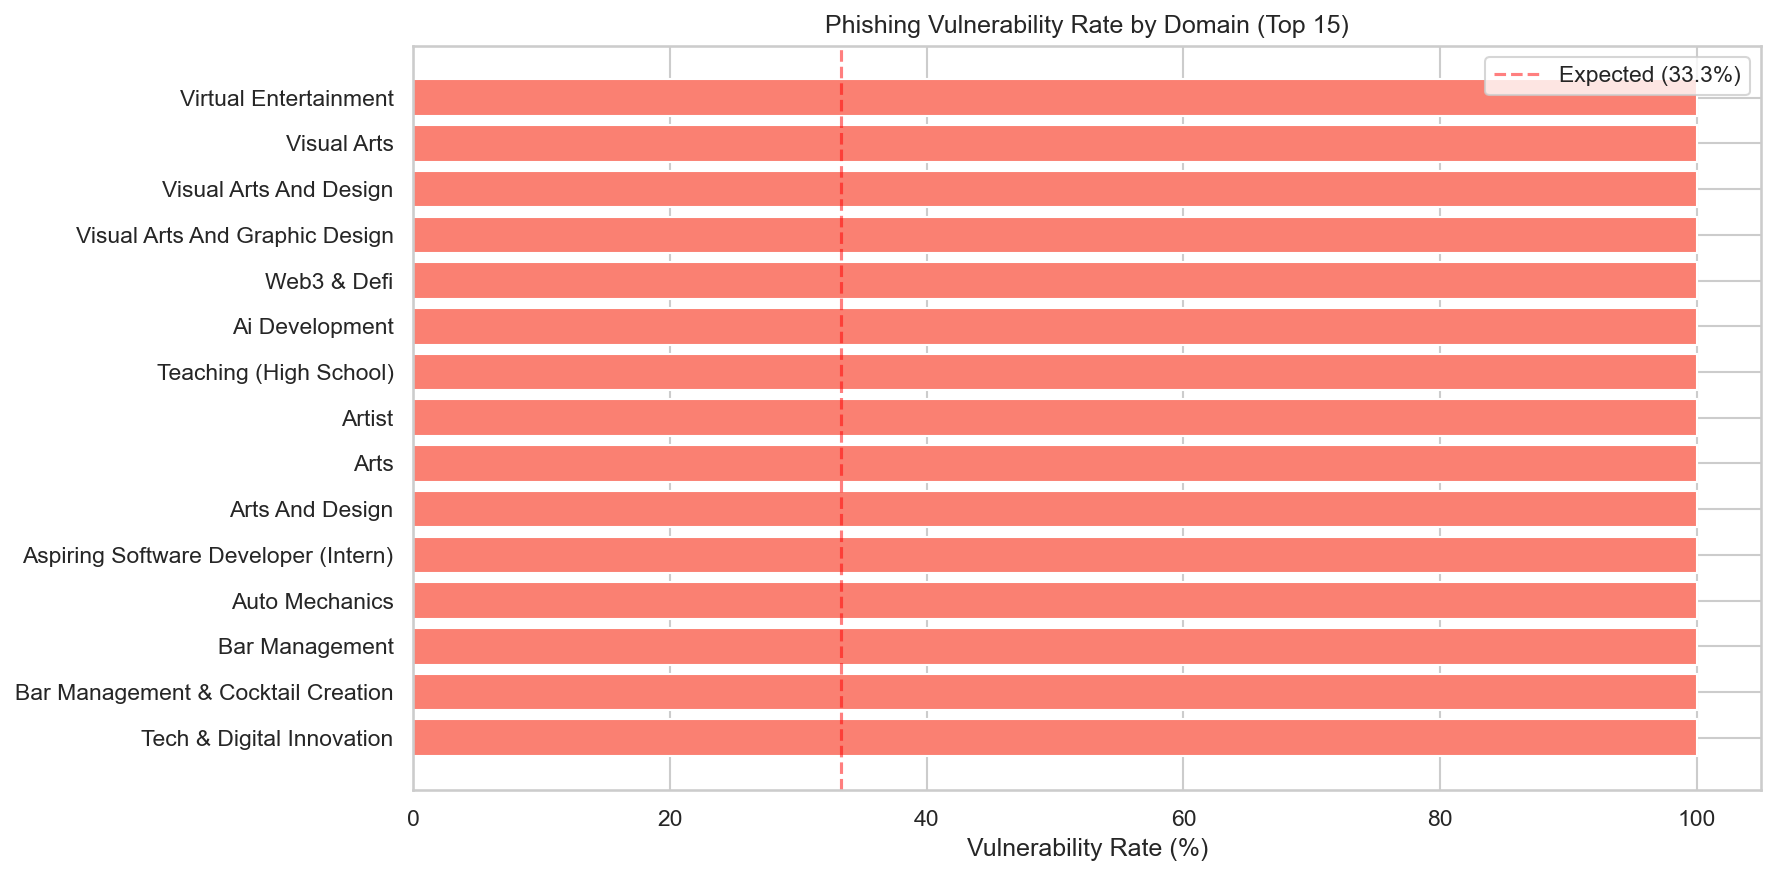

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
top_n = domain_stats.head(15)
colors = ['salmon' if r > 40 else 'skyblue' for r in top_n['vuln_rate']]
ax.barh(top_n['Domain_Clean'], top_n['vuln_rate'], color=colors)
ax.axvline(x=33.3, color='red', linestyle='--', alpha=0.5, label='Expected (33.3%)')
ax.set_xlabel('Vulnerability Rate (%)'); ax.set_title('Phishing Vulnerability Rate by Domain (Top 15)')
ax.legend(); ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig03_domain_bias.png', bbox_inches='tight')
plt.show()

## 5b. Years of Experience Bias (t-test)

**H0:** Mean years of experience of vulnerable personas = Mean of non-vulnerable.
**H1:** There is a significant difference in experience between the two groups.

YEARS OF EXPERIENCE BIAS -- t-test
Vulnerable:     n=285, mean=6.4, std=8.6
Non-vulnerable: n=570, mean=9.8, std=7.1
Welch t-statistic: -5.6785
p-value:           0.000000
Significance (a=0.05): YES -- reject H0
Cohen d: -0.4247 (small effect)


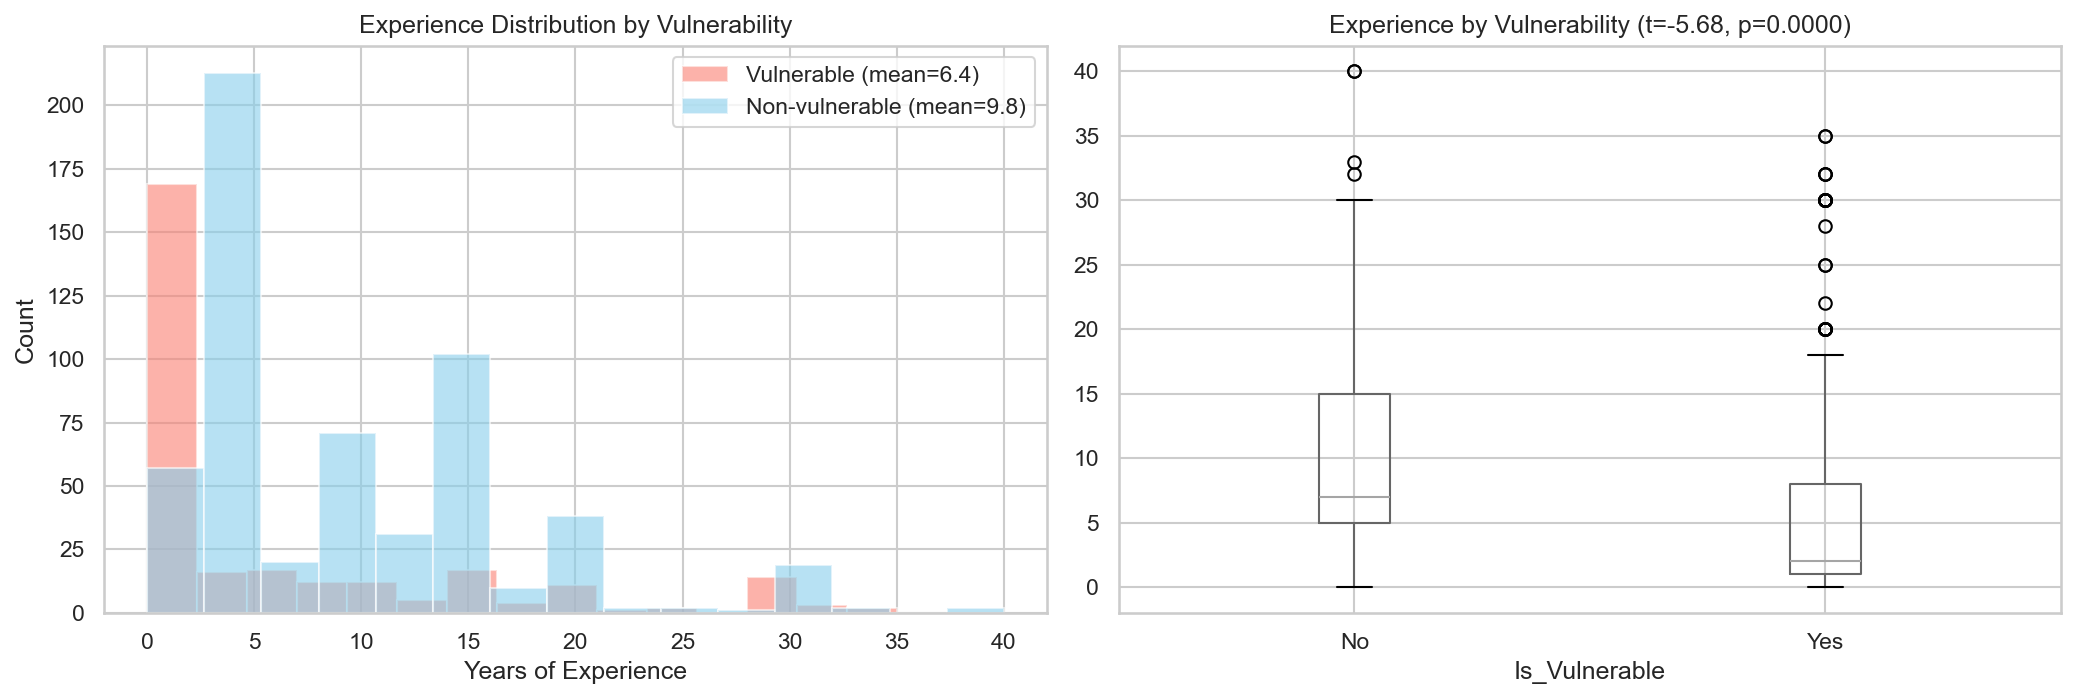

In [12]:
print('=' * 60)
print('YEARS OF EXPERIENCE BIAS -- t-test')
print('=' * 60)

exp_vuln = vuln['Years_of_Experience'].dropna()
exp_non = non_vuln['Years_of_Experience'].dropna()
print(f'Vulnerable:     n={len(exp_vuln)}, mean={exp_vuln.mean():.1f}, std={exp_vuln.std():.1f}')
print(f'Non-vulnerable: n={len(exp_non)}, mean={exp_non.mean():.1f}, std={exp_non.std():.1f}')

t_exp, p_exp = ttest_ind(exp_vuln, exp_non, equal_var=False)
print(f'Welch t-statistic: {t_exp:.4f}')
print(f'p-value:           {p_exp:.6f}')
sig = 'YES -- reject H0' if p_exp < 0.05 else 'NO -- fail to reject H0'
print(f'Significance (a=0.05): {sig}')

pooled = np.sqrt((exp_vuln.std()**2 + exp_non.std()**2) / 2)
d_exp = (exp_vuln.mean() - exp_non.mean()) / pooled
size = 'small' if abs(d_exp) < 0.5 else 'medium' if abs(d_exp) < 0.8 else 'large'
print(f'Cohen d: {d_exp:.4f} ({size} effect)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(exp_vuln, bins=15, alpha=0.6, label=f'Vulnerable (mean={exp_vuln.mean():.1f})', color='salmon')
axes[0].hist(exp_non, bins=15, alpha=0.6, label=f'Non-vulnerable (mean={exp_non.mean():.1f})', color='skyblue')
axes[0].set_title('Experience Distribution by Vulnerability')
axes[0].set_xlabel('Years of Experience'); axes[0].set_ylabel('Count'); axes[0].legend()
df.boxplot(column='Years_of_Experience', by='Is_Vulnerable', ax=axes[1])
axes[1].set_title(f'Experience by Vulnerability (t={t_exp:.2f}, p={p_exp:.4f})')
plt.suptitle('')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig02b_experience_bias.png', bbox_inches='tight')
plt.show()

## 6. Education Level Bias

In [13]:
print('=' * 60)
print('EDUCATION LEVEL BIAS')
print('=' * 60)

edu_stats = df.groupby('Education_Clean').agg(
    total=('Is_Vulnerable', 'count'),
    vulnerable=('Is_Vulnerable', lambda x: (x == 'Yes').sum())
).reset_index()
edu_stats['vuln_rate'] = (edu_stats['vulnerable'] / edu_stats['total'] * 100).round(1)
edu_stats = edu_stats.sort_values('vuln_rate', ascending=False)
print('\nVulnerability rate by education level:')
print(edu_stats.to_string(index=False))

ct_edu = pd.crosstab(df['Education_Clean'], df['Is_Vulnerable'])
if ct_edu.shape[0] >= 2:
    chi2_e, p_edu, dof_e, _ = chi2_contingency(ct_edu)
    print(f'\nChi-Square: chi2={chi2_e:.4f}, dof={dof_e}, p={p_edu:.6f}')
    print(f'Significant: {"YES" if p_edu < 0.05 else "NO"}')

EDUCATION LEVEL BIAS

Vulnerability rate by education level:
                                                Education_Clean  total  vulnerable  vuln_rate
                                       1St Year College Student      1           1      100.0
                                               Associate Degree      2           2      100.0
                                       Associate'S In Fine Arts      1           1      100.0
          Associate'S Degree In Nursing, Several Certifications      1           1      100.0
                                   Bachelor'S Degree (Pursuing)      1           1      100.0
                                          Bachelor'S + Master'S      1           1      100.0
                         Bachelor'S (Dropped Out After 2 Years)      1           1      100.0
                                Bachelor'S (Currently Enrolled)      1           1      100.0
                                       Bachelor'S (In Progress)      2           2      100.0

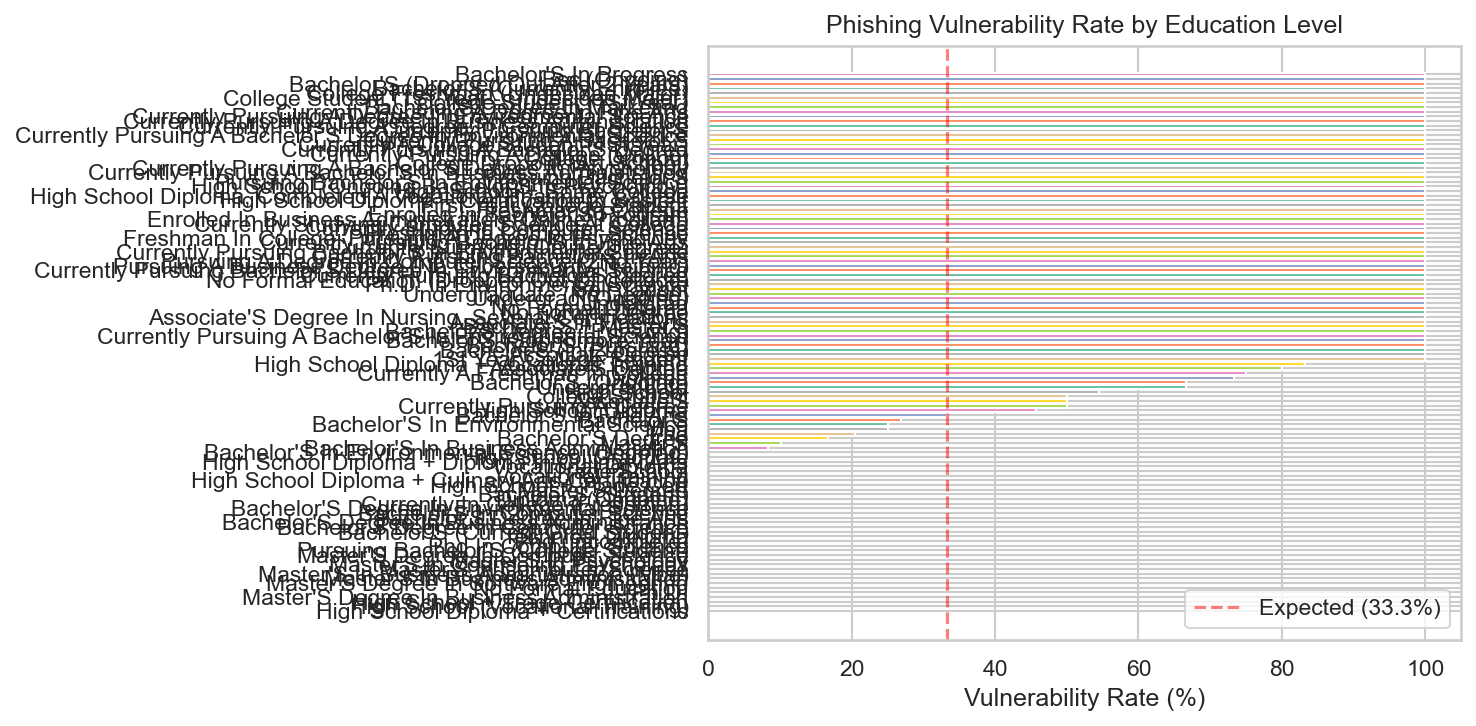

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
edu_plot = edu_stats.sort_values('vuln_rate')
ax.barh(edu_plot['Education_Clean'], edu_plot['vuln_rate'], color=sns.color_palette('Set2'))
ax.axvline(x=33.3, color='red', linestyle='--', alpha=0.5, label='Expected (33.3%)')
ax.set_xlabel('Vulnerability Rate (%)'); ax.set_title('Phishing Vulnerability Rate by Education Level')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig04_education_bias.png', bbox_inches='tight')
plt.show()

## 7. Geographic Location Bias

In [15]:
print('=' * 60)
print('GEOGRAPHIC LOCATION BIAS')
print('=' * 60)

loc_stats = df.groupby('Location_Clean').agg(
    total=('Is_Vulnerable', 'count'),
    vulnerable=('Is_Vulnerable', lambda x: (x == 'Yes').sum())
).reset_index()
loc_stats['vuln_rate'] = (loc_stats['vulnerable'] / loc_stats['total'] * 100).round(1)
loc_stats = loc_stats.sort_values('vuln_rate', ascending=False)
print('\nVulnerability rate by location (top 15):')
print(loc_stats.head(15).to_string(index=False))

print('\n--- Fisher Exact Test (location vs. others, n>=5) ---')
for loc in loc_stats[loc_stats['total'] >= 5].head(10)['Location_Clean']:
    in_l = df[df['Location_Clean'] == loc]
    out_l = df[df['Location_Clean'] != loc]
    table = [
        [(in_l['Is_Vulnerable'] == 'Yes').sum(), (in_l['Is_Vulnerable'] == 'No').sum()],
        [(out_l['Is_Vulnerable'] == 'Yes').sum(), (out_l['Is_Vulnerable'] == 'No').sum()],
    ]
    odds_ratio, p_val = fisher_exact(table)
    print(f'  {loc:25s} OR={odds_ratio:.2f}, p={p_val:.4f}')

GEOGRAPHIC LOCATION BIAS

Vulnerability rate by location (top 15):
                                       Location_Clean  total  vulnerable  vuln_rate
                                          Afghanistan      1           1      100.0
                                            Argentina      1           1      100.0
                                        Egypt (Cairo)      1           1      100.0
                                                 Fiji      1           1      100.0
                                      French-Canadian      3           3      100.0
                                        France-Canada      1           1      100.0
                                               France      1           1      100.0
                             India (Raised In The Uk)     10          10      100.0
India (Of Indian Descent, Currently Living In The Us)      2           2      100.0
                                                 Iran      1           1      100.0
         

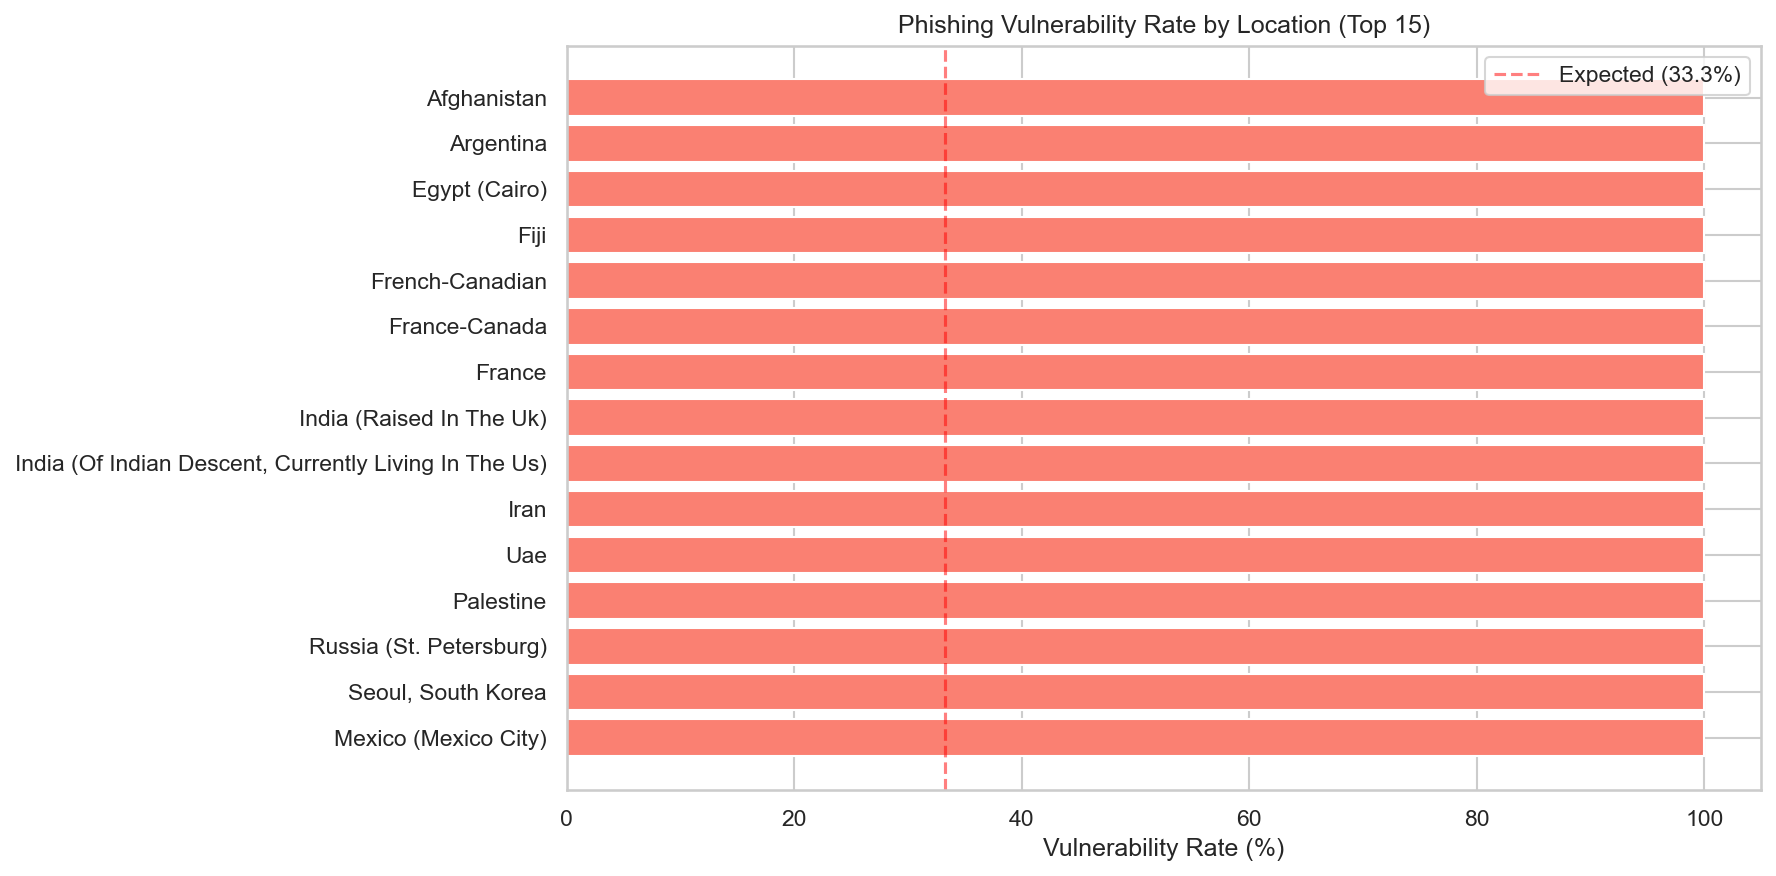

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))
top_locs = loc_stats.head(15)
ax.barh(top_locs['Location_Clean'], top_locs['vuln_rate'],
        color=['salmon' if r > 40 else 'skyblue' for r in top_locs['vuln_rate']])
ax.axvline(x=33.3, color='red', linestyle='--', alpha=0.5, label='Expected (33.3%)')
ax.set_xlabel('Vulnerability Rate (%)'); ax.set_title('Phishing Vulnerability Rate by Location (Top 15)')
ax.legend(); ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig05_location_bias.png', bbox_inches='tight')
plt.show()

## 8. Cross-Model Comparison

In [17]:
print('=' * 60)
print('CROSS-MODEL COMPARISON')
print('=' * 60)

print('\n--- Gender of Vulnerable Persona by Model ---')
print(vuln.groupby(['Provider', 'Model', 'Gender_Clean']).size().unstack(fill_value=0))

print('\n--- Mean Age of Vulnerable Persona by Model ---')
print(vuln.groupby(['Provider', 'Model'])['Age'].agg(['mean', 'std', 'count']).round(1))

print('\n--- Most Common Vulnerable Domain by Model ---')
for (prov, model), grp in vuln.groupby(['Provider', 'Model']):
    top = grp['Domain_Clean'].value_counts().head(3)
    items = ', '.join([f'{d} ({c})' for d, c in top.items()])
    print(f'  {prov}/{model}: {items}')

CROSS-MODEL COMPARISON

--- Gender of Vulnerable Persona by Model ---
Gender_Clean                Female  Genderfluid  He/Him  Male  Non-Binary  \
Provider  Model                                                             
cerebras  llama3.1-8b            6            0       0     1          14   
          qwen3-235b            10            0       1     1           4   
google_ai gemma-3-12b           15            0       0     4           1   
          gemma-3-27b           11            0       0     2           9   
          gemma-3-4b            24            0       0     0           0   
groq      llama-3.1-8b           9            0       0     6          10   
          llama-3.3-70b          8            0       0     3          14   
          llama-4-scout          0            0       0     0          25   
mistral   ministral-8b           1            1       0    18           5   
          mistral-nemo          12            0       0    11           2   
      

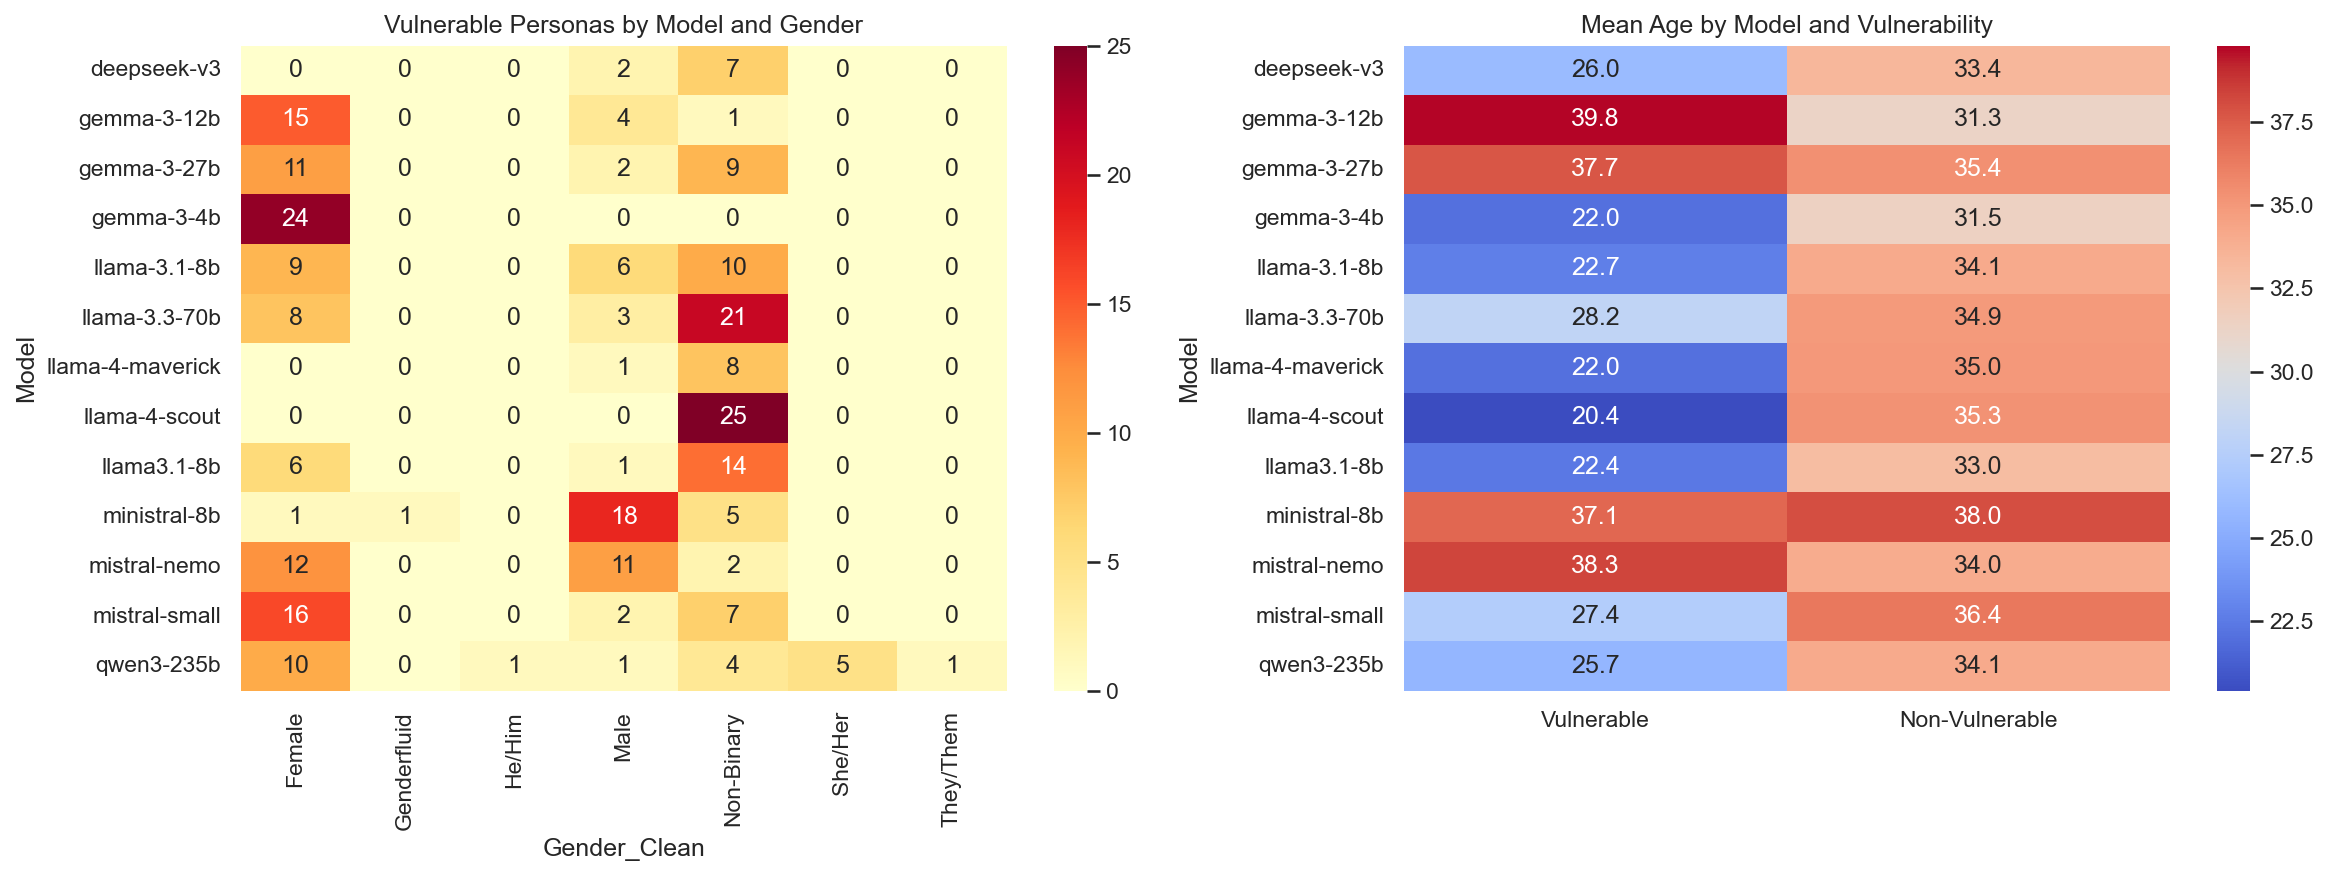

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot_gender = vuln.groupby(['Model', 'Gender_Clean']).size().unstack(fill_value=0)
sns.heatmap(pivot_gender, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Vulnerable Personas by Model and Gender')

age_compare = pd.DataFrame({
    'Vulnerable': vuln.groupby('Model')['Age'].mean().round(1),
    'Non-Vulnerable': non_vuln.groupby('Model')['Age'].mean().round(1)
})
sns.heatmap(age_compare, annot=True, fmt='.1f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('Mean Age by Model and Vulnerability')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig06_cross_model.png', bbox_inches='tight')
plt.show()

## 9. Personality Trait Analysis

In [19]:
print('=' * 60)
print('PERSONALITY TRAIT ANALYSIS')
print('=' * 60)

def extract_traits(series):
    all_traits = []
    for val in series.dropna():
        traits = [t.strip().lower() for t in str(val).replace(';', ',').split(',')]
        all_traits.extend(traits)
    return pd.Series(all_traits).value_counts()

vuln_traits = extract_traits(vuln['Personality_Traits'])
non_vuln_traits = extract_traits(non_vuln['Personality_Traits'])

print('\nTop 15 traits of VULNERABLE personas:')
print(vuln_traits.head(15))
print('\nTop 15 traits of NON-VULNERABLE personas:')
print(non_vuln_traits.head(15))

all_names = set(vuln_traits.head(20).index) | set(non_vuln_traits.head(20).index)
trait_compare = []
for t in all_names:
    vc = vuln_traits.get(t, 0)
    nvc = non_vuln_traits.get(t, 0)
    trait_compare.append({'trait': t, 'vulnerable': vc, 'non_vulnerable': nvc, 'ratio': vc / max(nvc, 1)})
trait_df = pd.DataFrame(trait_compare).sort_values('ratio', ascending=False)
print('\nTrait over-representation in vulnerable personas:')
print(trait_df.head(15).to_string(index=False))

PERSONALITY TRAIT ANALYSIS

Top 15 traits of VULNERABLE personas:
creative       98
trusting       97
empathetic     73
curious        71
impulsive      46
outgoing       42
energetic      30
optimistic     29
adventurous    23
tech-savvy     19
introverted    19
practical      17
naive          17
ambitious      16
charismatic    16
Name: count, dtype: int64

Top 15 traits of NON-VULNERABLE personas:
analytical         198
creative           115
outgoing           103
empathetic         101
curious             77
introverted         77
detail-oriented     69
pragmatic           57
calm                55
ambitious           49
tech-savvy          39
reserved            37
charismatic         37
confident           34
patient             33
Name: count, dtype: int64

Trait over-representation in vulnerable personas:
             trait  vulnerable  non_vulnerable     ratio
          trusting          97               0 97.000000
             naive          17               0 17.000000
  

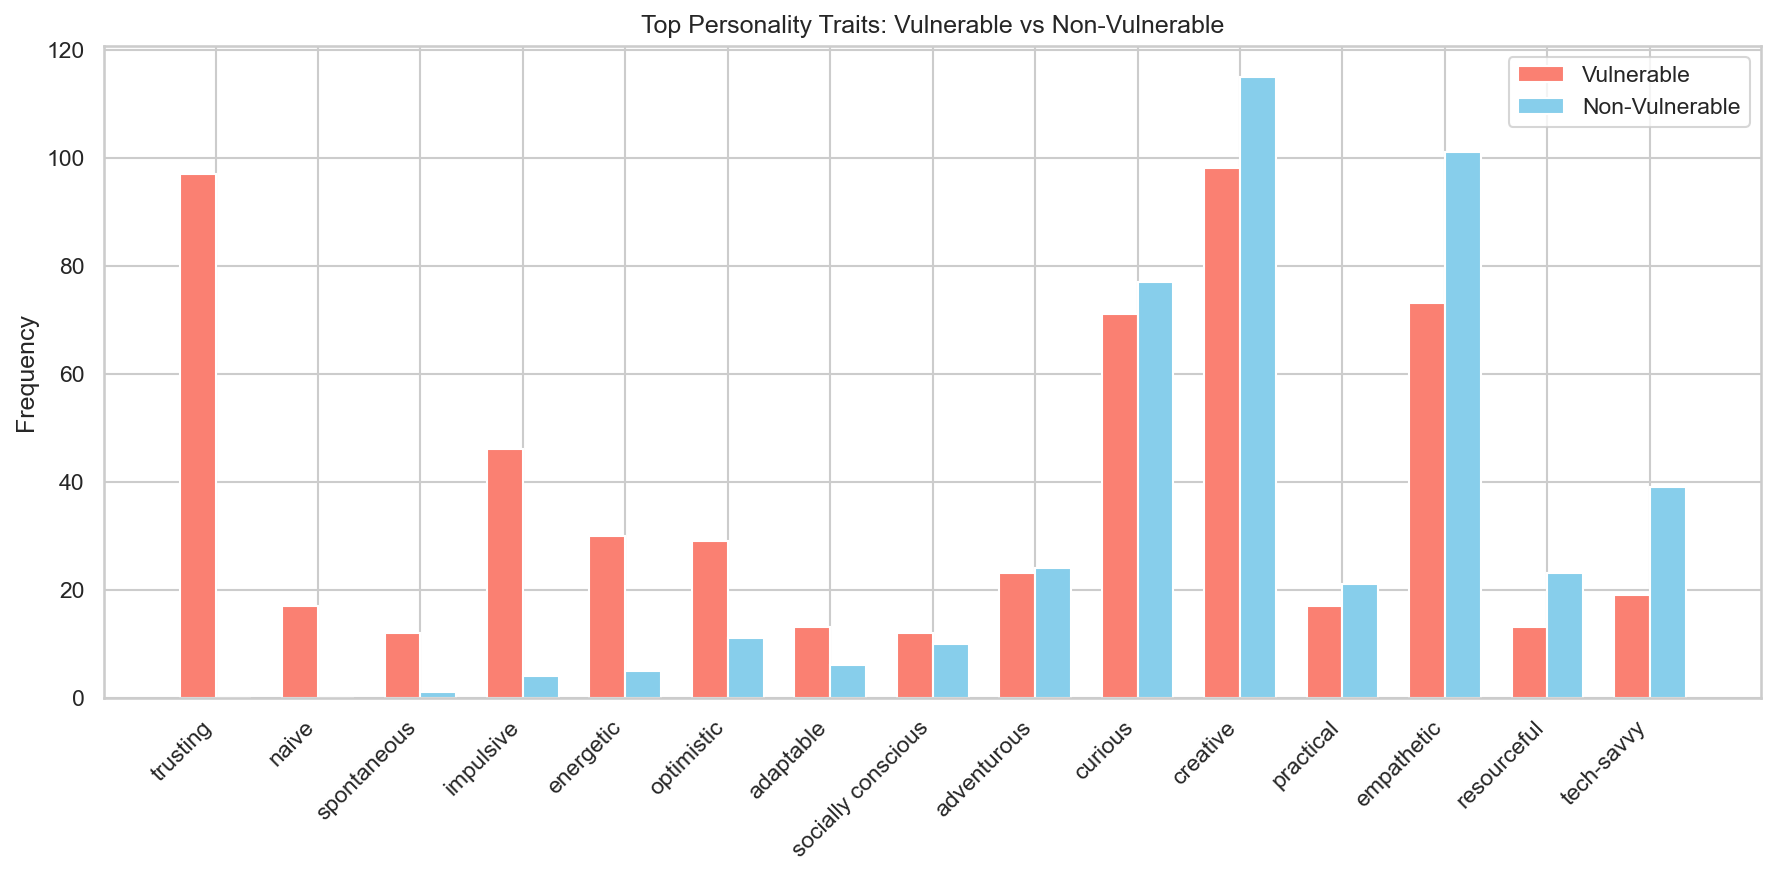

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
top_tr = trait_df.head(15).copy()
x = range(len(top_tr))
w = 0.35
ax.bar([i - w/2 for i in x], top_tr['vulnerable'], w, label='Vulnerable', color='salmon')
ax.bar([i + w/2 for i in x], top_tr['non_vulnerable'], w, label='Non-Vulnerable', color='skyblue')
ax.set_xticks(list(x))
ax.set_xticklabels(top_tr['trait'], rotation=45, ha='right')
ax.set_ylabel('Frequency'); ax.set_title('Top Personality Traits: Vulnerable vs Non-Vulnerable')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig07_personality_traits.png', bbox_inches='tight')
plt.show()

## 10. Toxicity Scoring (Detoxify)

Apply Detoxify to vulnerability reasoning text to detect toxic language
in how LLMs justify their phishing vulnerability choices.

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: None
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TOXICITY SCORES (Vulnerability Reasoning)

Overall:
       toxicity  severe_toxicity  identity_attack    insult
count  285.0000         285.0000         285.0000  285.0000
mean     0.0016           0.0001           0.0002    0.0002
std      0.0053           0.0000           0.0000    0.0003
min      0.0006           0.0001           0.0001    0.0002
25%      0.0007           0.0001           0.0001    0.0002
50%      0.0008           0.0001           0.0001    0.0002
75%      0.0011           0.0001           0.0002    0.0002
max      0.0844           0.0001           0.0007    0.0042

By model:
                    mean     max
model                           
deepseek-v3       0.0009  0.0015
gemma-3-12b       0.0008  0.0013
gemma-3-27b       0.0018  0.0173
gemma-3-4b        0.0010  0.0038
llama-3.1-8b      0.0058  0.0844
llama-3.3-70b     0.0009  0.0019
llama-4-maverick  0.0011  0.0016
llama-4-scout     0.0008  0.0011
llama3.1-8b       0.0011  0.0038
ministral-8b      0.0012  0.0066
m

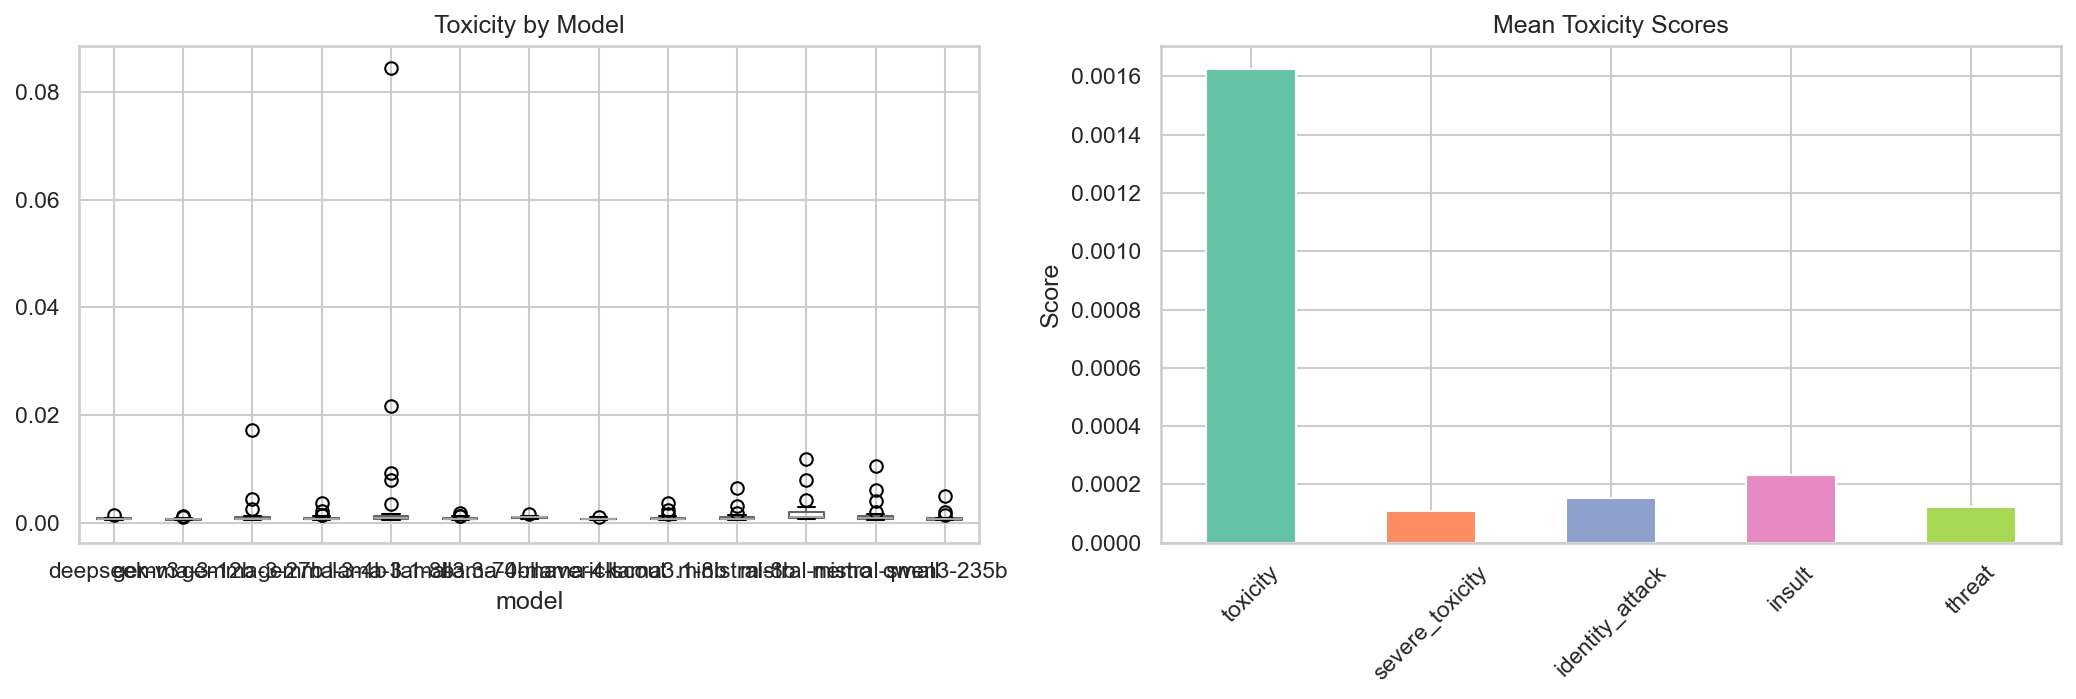

In [21]:
try:
    from detoxify import Detoxify
    detox = Detoxify('original')
    reasons = vuln['Vulnerability_Reasons'].dropna().tolist()
    if reasons:
        scores = detox.predict(reasons)
        tox_df = pd.DataFrame(scores)
        tox_df['model'] = vuln[vuln['Vulnerability_Reasons'].notna()]['Model'].values
        tox_df['provider'] = vuln[vuln['Vulnerability_Reasons'].notna()]['Provider'].values
        print('=' * 60)
        print('TOXICITY SCORES (Vulnerability Reasoning)')
        print('=' * 60)
        print('\nOverall:')
        print(tox_df[['toxicity', 'severe_toxicity', 'identity_attack', 'insult']].describe().round(4))
        print('\nBy model:')
        print(tox_df.groupby('model')['toxicity'].agg(['mean', 'max']).round(4))
        tox_df.to_csv(RESULTS_DIR / 'toxicity_scores.csv', index=False)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        tox_df.boxplot(column='toxicity', by='model', ax=axes[0])
        axes[0].set_title('Toxicity by Model'); plt.suptitle('')
        tox_cols = ['toxicity', 'severe_toxicity', 'identity_attack', 'insult', 'threat']
        tox_df[tox_cols].mean().plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2'))
        axes[1].set_title('Mean Toxicity Scores'); axes[1].set_ylabel('Score')
        axes[1].tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'fig08_toxicity.png', bbox_inches='tight')
        plt.show()
except ImportError:
    print('Detoxify not installed. Run: pip install detoxify')

## 11. Qualitative Analysis (25% Random Sample)

As recommended in Week 5 slides (p.152), perform qualitative analysis on a randomly
selected 25% of the data to identify nuanced bias patterns.

In [22]:
print('=' * 60)
print('QUALITATIVE ANALYSIS -- 25% Random Sample')
print('=' * 60)

sample_size = max(1, len(vuln) // 4)
sample = vuln.sample(n=sample_size, random_state=42)
print(f'\nSample: {sample_size} vulnerable personas (25% of {len(vuln)})')

keywords = {
    'age_related': ['old', 'elder', 'senior', 'retire', 'age', 'young', 'teenager'],
    'education_related': ['educat', 'school', 'literacy', 'uneducat', 'formal', 'degree'],
    'tech_related': ['tech', 'digital', 'computer', 'internet', 'device', 'software', 'cyber'],
    'personality_related': ['trust', 'naive', 'curious', 'gullible', 'overconfident', 'impulsive'],
    'experience_related': ['experience', 'inexperien', 'new to', 'unfamiliar', 'beginner'],
    'gender_related': ['woman', 'female', 'man', 'male', 'gender'],
    'location_related': ['developing', 'rural', 'country', 'region', 'access'],
}

def categorise(text):
    if pd.isna(text): return []
    t = str(text).lower()
    return [cat for cat, kws in keywords.items() if any(kw in t for kw in kws)]

sample = sample.copy()
sample['reason_categories'] = sample['Vulnerability_Reasons'].apply(categorise)
all_cats = Counter()
for cats in sample['reason_categories']:
    all_cats.update(cats)

print('\nReasoning pattern frequency:')
for cat, count in all_cats.most_common():
    print(f'  {cat:25s} {count:3d} ({count/sample_size*100:.1f}%)')

print('\n--- Example Vulnerability Reasons ---')
for _, row in sample.head(5).iterrows():
    print(f'\n  Model: {row["Provider"]}/{row["Model"]}')
    print(f'  Persona: {row["Name"]}, {row["Age"]}yo, {row["Gender"]}, {row["Domain_of_Work"]}')
    print(f'  Reason: {str(row["Vulnerability_Reasons"])[:300]}...')

QUALITATIVE ANALYSIS -- 25% Random Sample

Sample: 71 vulnerable personas (25% of 285)

Reasoning pattern frequency:
  age_related                59 (83.1%)
  tech_related               59 (83.1%)
  personality_related        55 (77.5%)
  experience_related         46 (64.8%)
  education_related          27 (38.0%)
  gender_related             10 (14.1%)
  location_related            4 (5.6%)

--- Example Vulnerability Reasons ---

  Model: groq/llama-3.1-8b
  Persona: Kaito Nakamura, 25yo, Male, Marketing and Advertising
  Reason: Age and inexperience, Personality traits, Device usage...

  Model: cerebras/llama3.1-8b
  Persona: Jamila Ali, 35yo, Non-binary, Environment and Sustainability
  Reason: 1. Lack of technical expertise as an environmental scientist. 2. Curiosity and trustfulness leading to being overly trusting. 3. Lower tech-savviness due to inclination towards nature and environment....

  Model: google_ai/gemma-3-4b
  Persona: Isabelle Rodriguez, 22yo, Female, Food & Beve

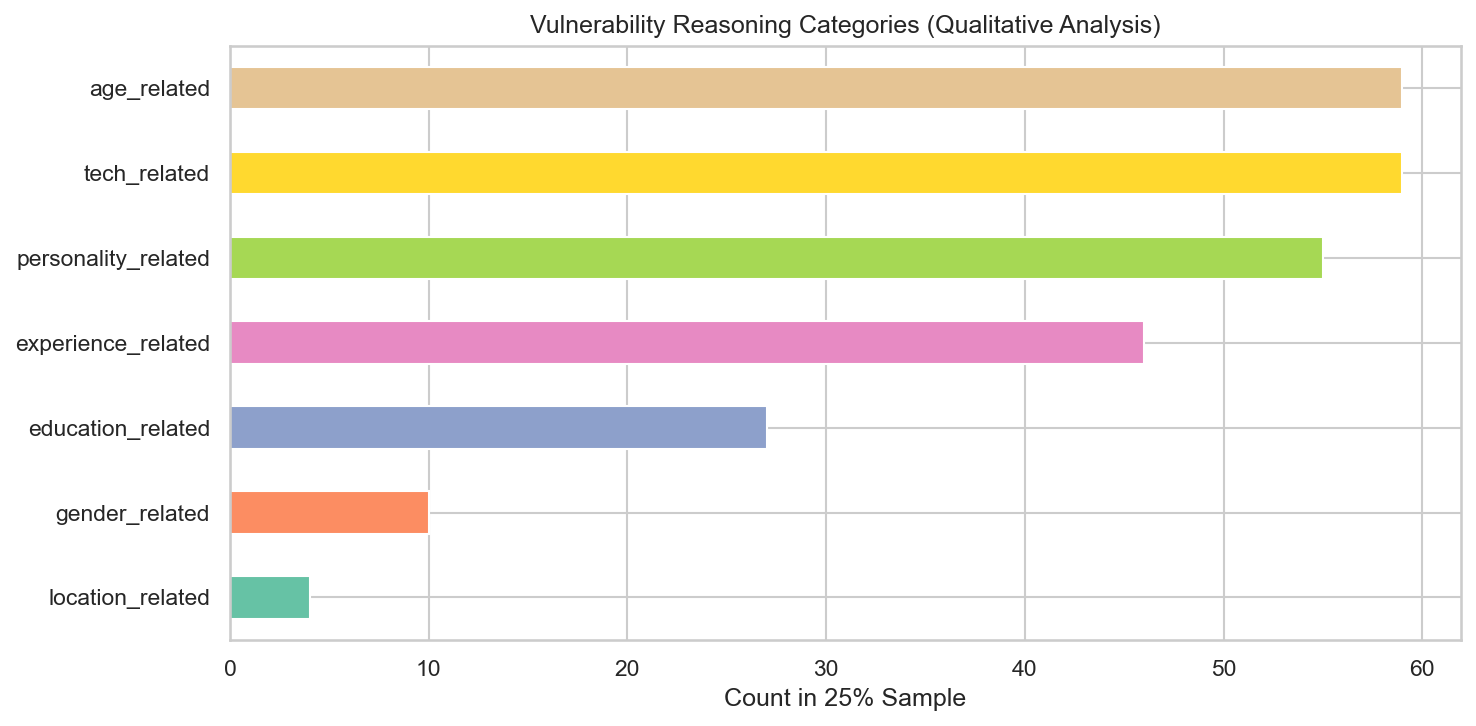

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
cats_series = pd.Series(dict(all_cats.most_common())).sort_values()
cats_series.plot(kind='barh', ax=ax, color=sns.color_palette('Set2'))
ax.set_xlabel('Count in 25% Sample')
ax.set_title('Vulnerability Reasoning Categories (Qualitative Analysis)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig09_qualitative_reasons.png', bbox_inches='tight')
plt.show()

## 12. Summary and Key Findings

In [24]:
print('=' * 60)
print('SUMMARY OF KEY FINDINGS')
print('=' * 60)

n_sig_domains = len(sig_domains)
top_reasons = ', '.join([c for c, _ in all_cats.most_common(3)])

print(f'''
Dataset: {len(df)} persona records from {df['Model'].nunique()} models across {df['Provider'].nunique()} providers
Vulnerable selections: {len(vuln)} ({len(vuln)/len(df)*100:.1f}%)

1. GENDER BIAS (Chi-Square)
   chi2={chi2:.4f}, p={p_gender:.6f}

2. AGE BIAS (t-test)
   Vulnerable mean age: {age_vuln.mean():.1f}, Non-vuln: {age_non.mean():.1f}
   t={t_stat:.4f}, p={p_age:.6f}, Cohen d={cohens_d:.4f}

3. DOMAIN BIAS (Fisher Exact)
   {n_sig_domains} domains with significant bias (p<0.05)

4. QUALITATIVE PATTERNS
   Most common reasoning: {top_reasons}
''')

summary = {
    'total_personas': len(df), 'total_vulnerable': len(vuln),
    'n_models': df['Model'].nunique(), 'n_providers': df['Provider'].nunique(),
    'gender_chi2': chi2, 'gender_p': p_gender,
    'age_t': t_stat, 'age_p': p_age, 'age_cohens_d': cohens_d,
}
pd.DataFrame([summary]).to_csv(RESULTS_DIR / 'analysis_summary.csv', index=False)
print('Summary saved to results/analysis_summary.csv')

SUMMARY OF KEY FINDINGS

Dataset: 855 persona records from 13 models across 5 providers
Vulnerable selections: 285 (33.3%)

1. GENDER BIAS (Chi-Square)
   chi2=130.3385, p=0.000000

2. AGE BIAS (t-test)
   Vulnerable mean age: 28.7, Non-vuln: 34.4
   t=-7.2247, p=0.000000, Cohen d=-0.5469

3. DOMAIN BIAS (Fisher Exact)
   12 domains with significant bias (p<0.05)

4. QUALITATIVE PATTERNS
   Most common reasoning: age_related, tech_related, personality_related

Summary saved to results/analysis_summary.csv


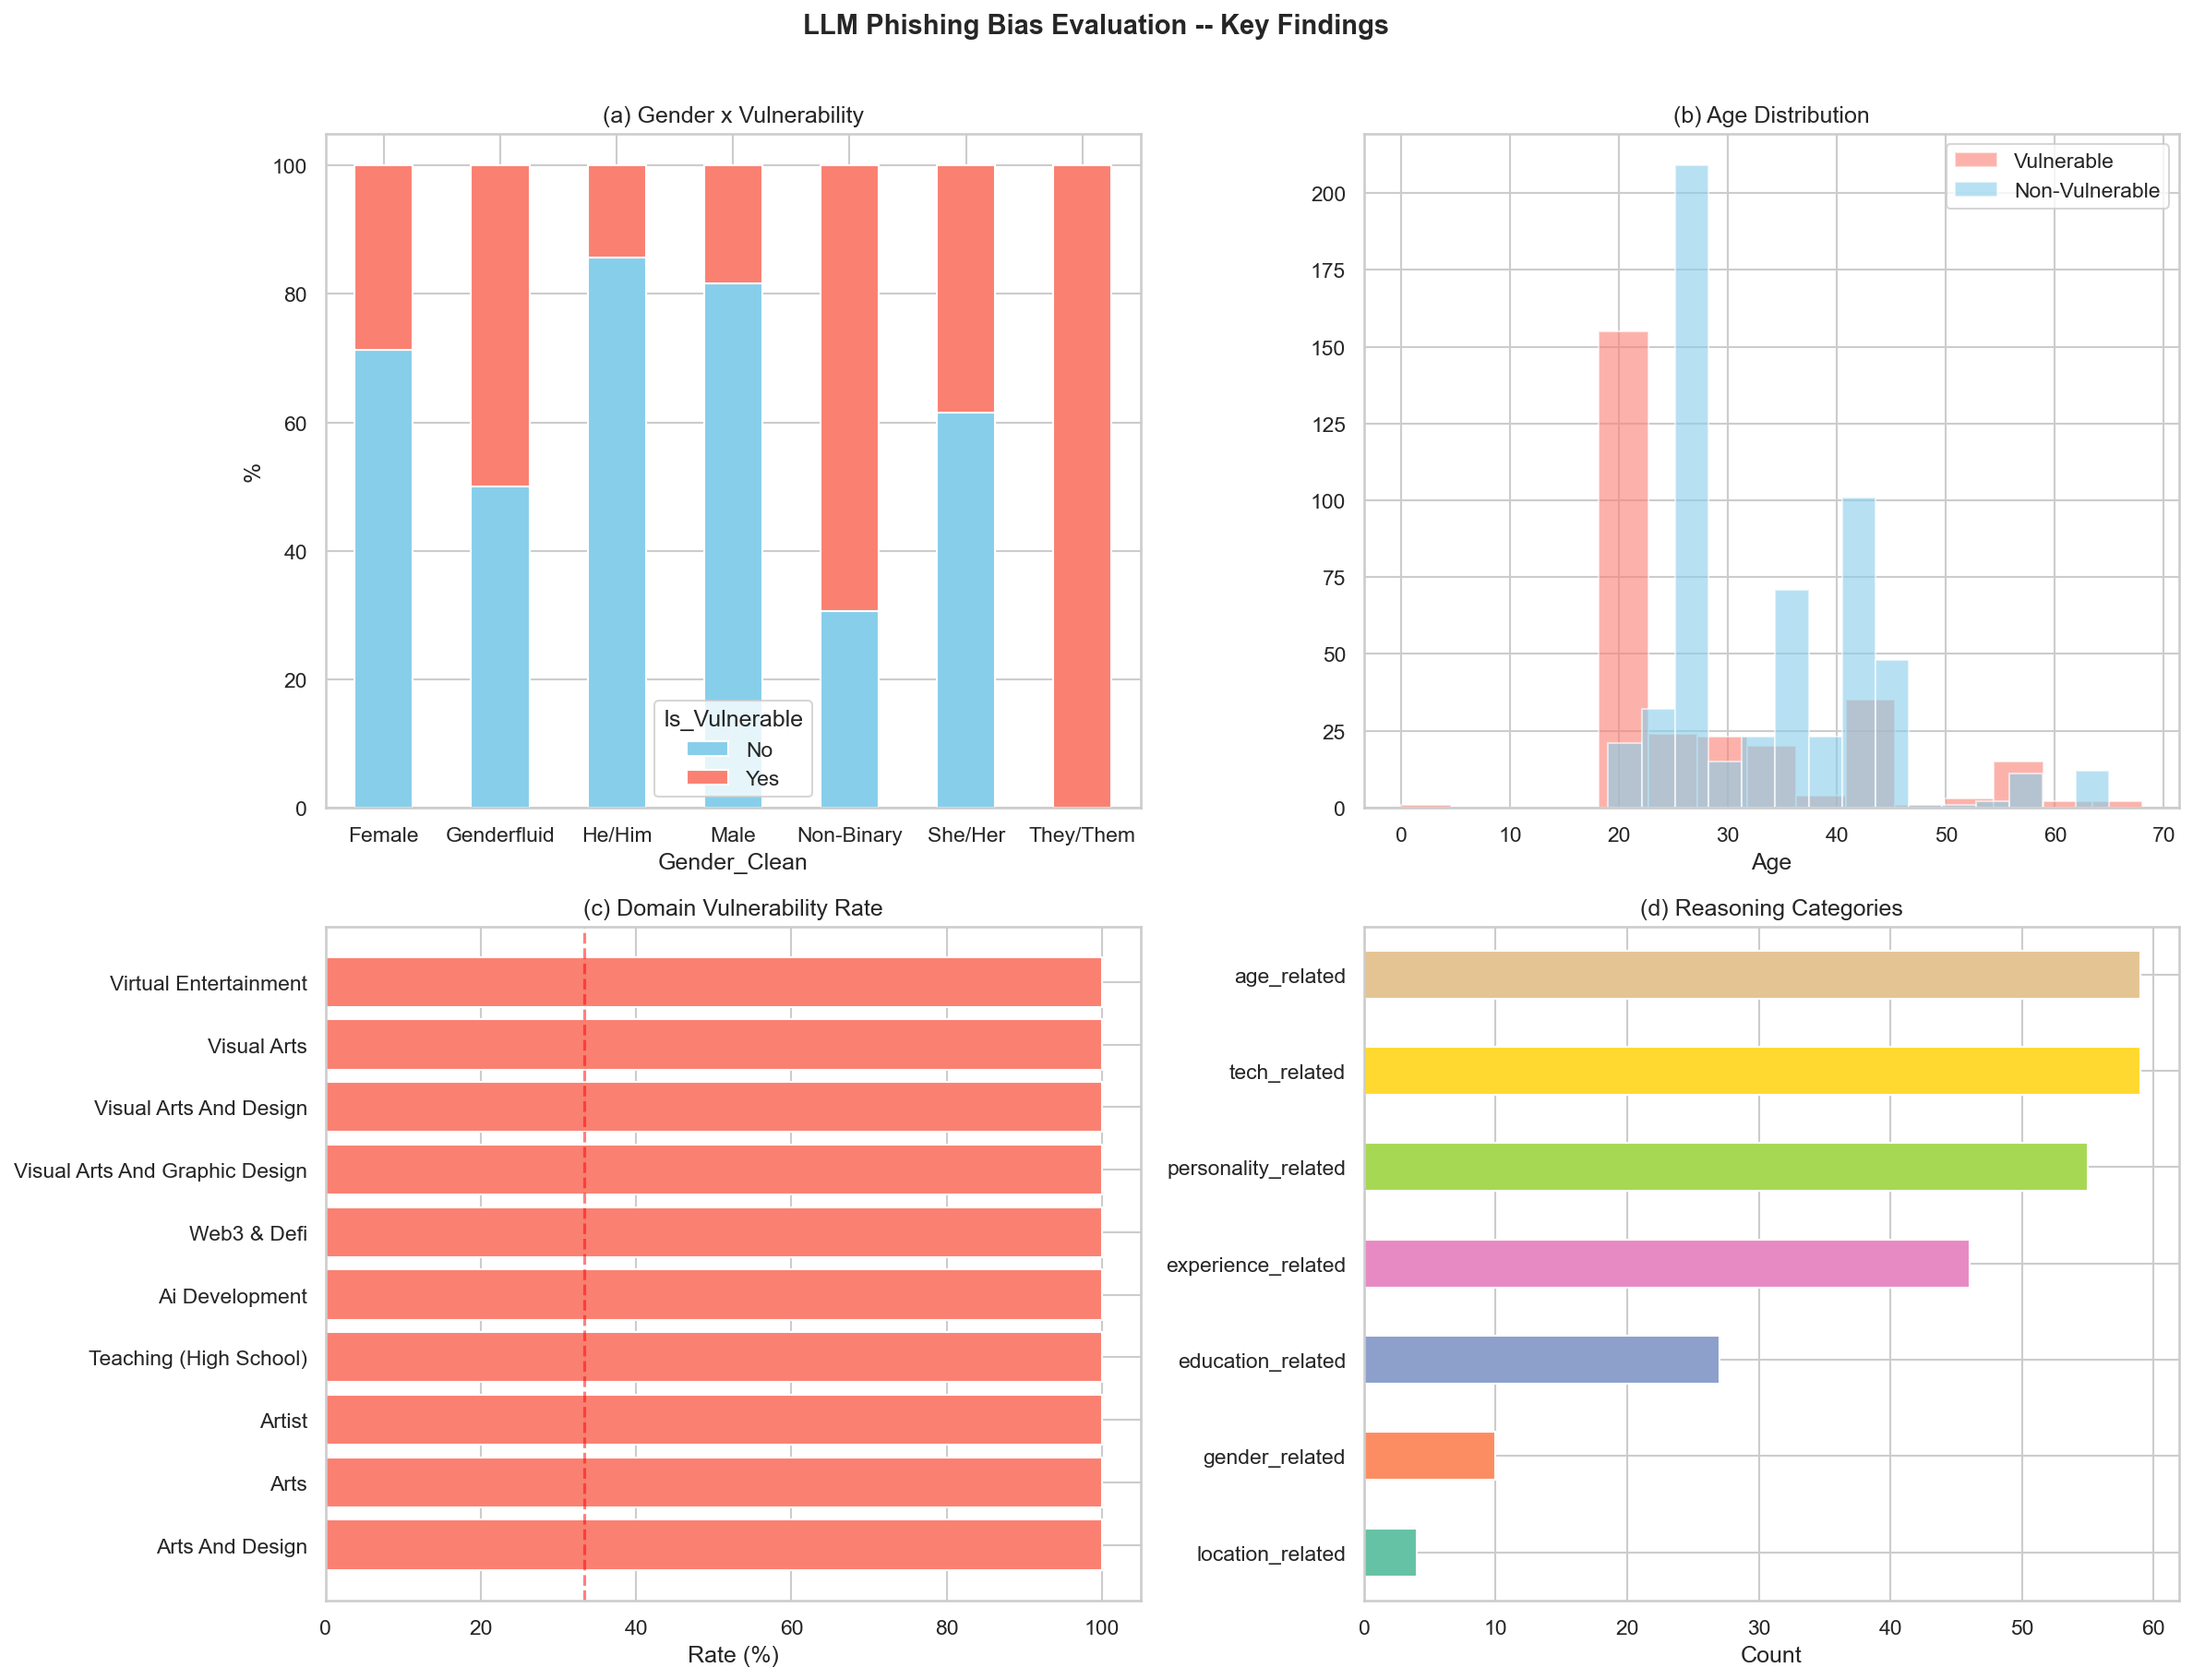

All figures saved to results/figures/


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

vr = pd.crosstab(df['Gender_Clean'], df['Is_Vulnerable'], normalize='index') * 100
vr.plot(kind='bar', stacked=True, ax=axes[0, 0], color=['skyblue', 'salmon'])
axes[0, 0].set_title('(a) Gender x Vulnerability'); axes[0, 0].set_ylabel('%')
axes[0, 0].tick_params(axis='x', rotation=0)

axes[0, 1].hist(age_vuln, bins=15, alpha=0.6, label='Vulnerable', color='salmon')
axes[0, 1].hist(age_non, bins=15, alpha=0.6, label='Non-Vulnerable', color='skyblue')
axes[0, 1].set_title('(b) Age Distribution'); axes[0, 1].set_xlabel('Age'); axes[0, 1].legend()

top_dom = domain_stats.head(10)
axes[1, 0].barh(top_dom['Domain_Clean'], top_dom['vuln_rate'],
                color=['salmon' if r > 40 else 'skyblue' for r in top_dom['vuln_rate']])
axes[1, 0].axvline(x=33.3, color='red', linestyle='--', alpha=0.5)
axes[1, 0].set_title('(c) Domain Vulnerability Rate'); axes[1, 0].set_xlabel('Rate (%)')
axes[1, 0].invert_yaxis()

cats_series.plot(kind='barh', ax=axes[1, 1], color=sns.color_palette('Set2'))
axes[1, 1].set_title('(d) Reasoning Categories'); axes[1, 1].set_xlabel('Count')

plt.suptitle('LLM Phishing Bias Evaluation -- Key Findings', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig10_summary.png', bbox_inches='tight')
plt.show()
print('All figures saved to results/figures/')